# Testing New Pointing Operators

Date: 16 September 2026

---

# Basics of TOAST

In [353]:
# Optionally change logging level
import os
os.environ["TOAST_LOGLEVEL"] = "INFO"
# This is needed before importing toast, and should
# match the value passed to the '-t' option of %toast
os.environ["OMP_NUM_THREADS"] = "8"

# TOAST interactive startup
import toast.interactive
%reload_ext toast.interactive

In [354]:
%toast -p 1 -t 8 -a

TOAST INFO: Using 1 processes with 8 threads each.


In [355]:
import numpy as np
import astropy.units as u
from astropy.table import QTable
import pandas as pd
import os

import toast
from toast.tests import helpers
import inspect
from plotting_utils import *
import healpy as hp
from toast.vis import plot_projected_quats
import toast.qarray as qa
%matplotlib inline


out_dir = 'out_sim_ground/custom_map'

In [356]:
# MPI communicator
world, procs, rank = toast.mpi.get_world()
comm = helpers.create_comm(world, single_group=True)

print(world, procs, rank)

<mpi4py.MPI.Intracomm object at 0x7f0b1200d440> 1 0


TOAST is built using an object-oriented approach to data management. The top level container is a `Data` object. Each `Data` object is made up of a list of `Observations`, which themselves contain information for a given `Telescope`. 

More on these objects will be introduced later, but for now, we need to define our telescope.

## Making a Telescope

The `Telescope` Object requires two vital pieces of information. 
- A telescope `Site`
- A `FocalPlane`

Let's define our telescope site:

TOAST has two built-in site classes (`GroundSite` and `SpaceSite`) built on the base class `Site`.

`GroundSite` defines a ground based site and requires a <span style="color:lightgreen">name, lat, long, alt</span>. Additionally, it can take in <span style="color:lightgreen">weather</span> data.

`SpaceSite` represents a telescope site with no atmosphere. It requires only a _name_ to define.

In [357]:

site = toast.instrument.GroundSite("atacama", "-22:57:30", "-67:47:10", 5200.0 * u.meter)

spacesite = toast.instrument.SpaceSite("HNSpaceTelescope")

Now we can define our `FocalPlane` object.

TOAST has multiple methods for creating focal plane models of varying complexity.

`toast.instrument_sim` has three functions for creating simulated focal planes:
- `fake_hexagon_focalplane` - creates a simple hexagon-packed focal plane. Not the most realistic but a simple implementation.
- `fake_rhombihex_focalplane` - creates a simple focal plane built up of 3 rhombi. Not the most realistic but a simple implementation. The number of pixels per rhombus (<span style="color:lightgreen">n_pix_rhombus</span>) must be a square number.
- `fake_boresight_focalplane` - Create a focalplane with all detectors at the boresight for testing.


In [358]:
from toast.instrument_sim import (
    fake_rhombihex_focalplane,
    fake_boresight_focalplane,
    fake_hexagon_focalplane,
    plot_focalplane
)

In [359]:
fp_fwhm = 30.0 * u.arcmin

focalplane = fake_rhombihex_focalplane(
    n_pix_rhombus=25,# Number of pixels per rhombus must be a perfect square
    width=8.0 * u.degree, # field of view of the focal plane
    gap=0 * u.radian,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
    fwhm=fp_fwhm, # Beam size
    bandcenter=150 * u.GHz,
    bandwidth=20 * u.GHz,
    psd_net=300.0 * u.uK * np.sqrt(1 * u.second),
    psd_fmin=1.0e-5 * u.Hz,
    psd_alpha=1.0,
    psd_fknee=0.05 * u.Hz,
    fwhm_sigma=0.0 * u.arcmin,
    bandcenter_sigma=0 * u.GHz,
    bandwidth_sigma=0 * u.GHz,
    random_seed=123456,
)
fov = focalplane.field_of_view

<span style="color:red">Note:</span> This `FocalPlane` only considers one frequency band. For a dichroic/multichroic focal plane, it currently seems like you need to model another `FocalPlane` object.

We can plot that `FocalPlane` using:

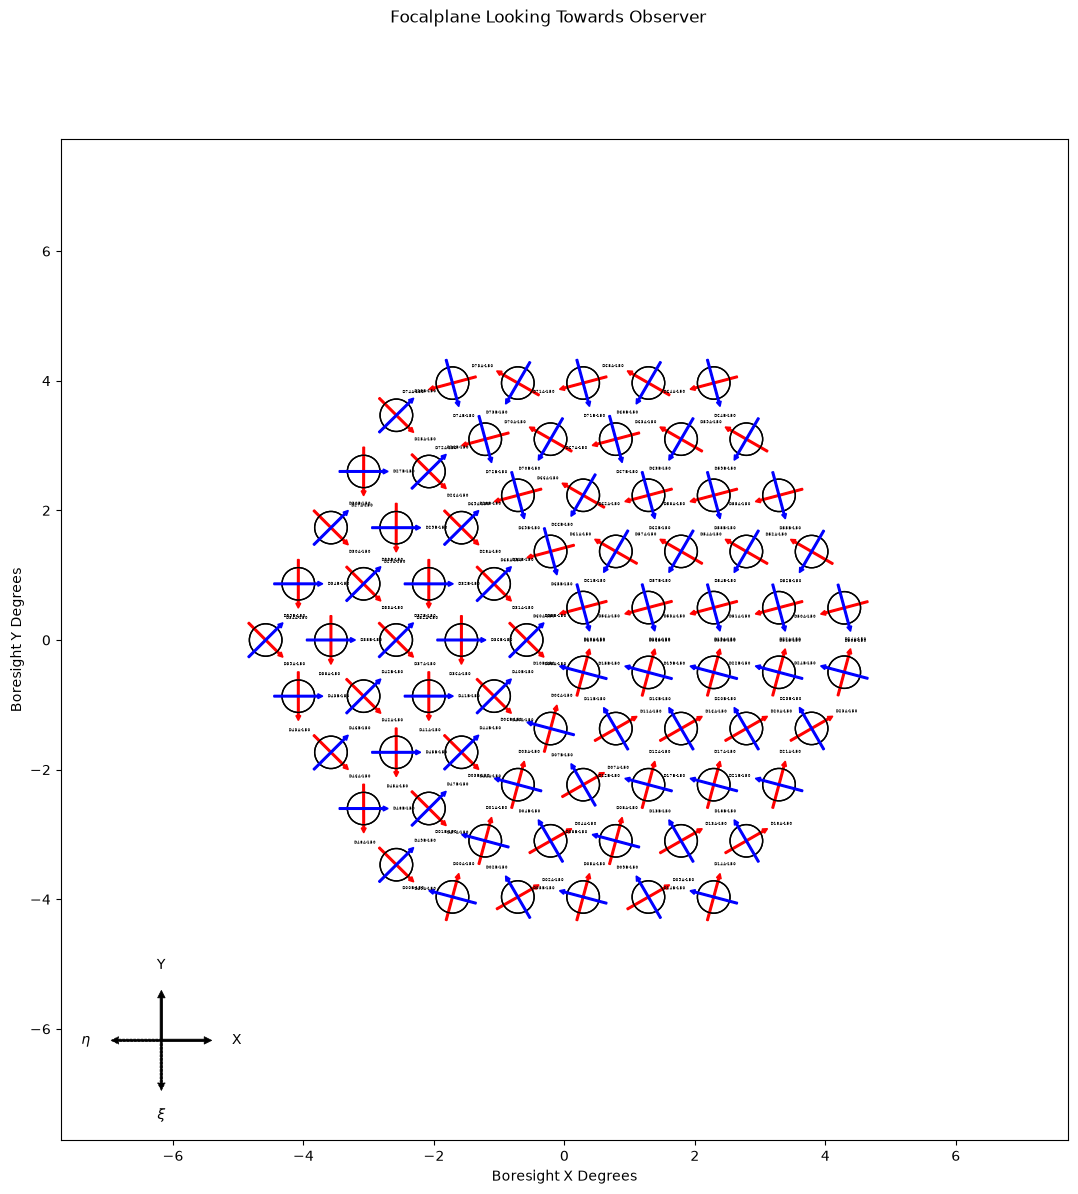

In [360]:
# We will define colors for our two polarization angles
detpolcol = {
    x: "red" if "A" in x else "blue" for x in focalplane.detectors
}

# Plot the focal plane
_ = plot_focalplane(
    focalplane=focalplane,
    width=1.3 * fov,
    height=1.3 * fov,
    show_labels=True,
    pol_color=detpolcol
)

Now that we have defined both our `FocalPlane` and out `Site`. We can make our `Telescope` object.

In [361]:
telescope = toast.Telescope(name="HenryTelescope", focalplane = focalplane, site = site)

## Exploring our Telescope

Now that we have made a `Telescope`. How do we access the information is stored in the object?

In [362]:
print(type(focalplane))
print(focalplane)

<class 'toast.instrument.Focalplane'>
<Focalplane: 150 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D74B-150]>


In [363]:
print(focalplane.detectors)
print(focalplane.n_detectors)

[np.str_('D00A-150'), np.str_('D00B-150'), np.str_('D01A-150'), np.str_('D01B-150'), np.str_('D02A-150'), np.str_('D02B-150'), np.str_('D03A-150'), np.str_('D03B-150'), np.str_('D04A-150'), np.str_('D04B-150'), np.str_('D05A-150'), np.str_('D05B-150'), np.str_('D06A-150'), np.str_('D06B-150'), np.str_('D07A-150'), np.str_('D07B-150'), np.str_('D08A-150'), np.str_('D08B-150'), np.str_('D09A-150'), np.str_('D09B-150'), np.str_('D10A-150'), np.str_('D10B-150'), np.str_('D11A-150'), np.str_('D11B-150'), np.str_('D12A-150'), np.str_('D12B-150'), np.str_('D13A-150'), np.str_('D13B-150'), np.str_('D14A-150'), np.str_('D14B-150'), np.str_('D15A-150'), np.str_('D15B-150'), np.str_('D16A-150'), np.str_('D16B-150'), np.str_('D17A-150'), np.str_('D17B-150'), np.str_('D18A-150'), np.str_('D18B-150'), np.str_('D19A-150'), np.str_('D19B-150'), np.str_('D20A-150'), np.str_('D20B-150'), np.str_('D21A-150'), np.str_('D21B-150'), np.str_('D22A-150'), np.str_('D22B-150'), np.str_('D23A-150'), np.str_('D23

Detector information is stored in the `FocalPlane.detector_data` attribute. This is an `astropy.QTable` object and can be viewed using the astropy `show_in_notebook` method.

In [364]:
print(focalplane.properties)
print(type(focalplane.detector_data))
focalplane.detector_data.show_in_notebook()

['name', 'quat', 'pol_leakage', 'psi_pol', 'gamma', 'fwhm', 'psd_fmin', 'psd_fknee', 'psd_alpha', 'psd_net', 'bandcenter', 'bandwidth', 'pixel', 'uid', 'pol_angle', 'pol_efficiency']
<class 'astropy.table.table.QTable'>


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Another useful focal plane function is the `detector_groups` method. 

This selects a column of the `detector_data` and returns a dictionary where the keys are the unique values in that column, and the values are the corresponding detector names.

In [365]:
# For example, we can split our detectors by polarization
psi_pol_dict = focalplane.detector_groups(column='psi_pol')
print(f"This dictionary has two keys, one for each polarization state {psi_pol_dict.keys()}")
psi_pol_list = list(psi_pol_dict.items())
print(f"The detectors corresponding to polarization state: {psi_pol_list[0][0]} are\n{psi_pol_list[0][1]}")

This dictionary has two keys, one for each polarization state dict_keys([<Quantity 0. rad>, <Quantity 1.57079633 rad>])
The detectors corresponding to polarization state: 0.0 rad are
[np.str_('D00A-150'), np.str_('D01A-150'), np.str_('D02A-150'), np.str_('D03A-150'), np.str_('D04A-150'), np.str_('D05A-150'), np.str_('D06A-150'), np.str_('D07A-150'), np.str_('D08A-150'), np.str_('D09A-150'), np.str_('D10A-150'), np.str_('D11A-150'), np.str_('D12A-150'), np.str_('D13A-150'), np.str_('D14A-150'), np.str_('D15A-150'), np.str_('D16A-150'), np.str_('D17A-150'), np.str_('D18A-150'), np.str_('D19A-150'), np.str_('D20A-150'), np.str_('D21A-150'), np.str_('D22A-150'), np.str_('D23A-150'), np.str_('D24A-150'), np.str_('D25A-150'), np.str_('D26A-150'), np.str_('D27A-150'), np.str_('D28A-150'), np.str_('D29A-150'), np.str_('D30A-150'), np.str_('D31A-150'), np.str_('D32A-150'), np.str_('D33A-150'), np.str_('D34A-150'), np.str_('D35A-150'), np.str_('D36A-150'), np.str_('D37A-150'), np.str_('D38A-150'

# Observation Data

In TOAST the data is treated as an object upon which operations act. `Operators`, typically found in the `toast.ops` module, define some set of operations to perform on the data. This can range from applying pointing to saving objects to file. The standard syntax for applying an operation is:
```python
operation = toast.ops.<OperatorName>(*args, **kwargs)
operation.apply(data)
```

An example observation simulation might be composed of the following steps:
1. Apply a schedule to the data - data indicating telescope motion etc.
2. Apply detector pointing to the data
3. Apply a scan of a simulated CMB to the data
4. Apply noise to the data
5. Apply Scan Synchronous Signals like ground pickup
6. Apply a simulated atmosphere

Let's see this in action:

In [366]:
# Start with an empty data container
data = toast.Data(comm)

## Observing Schedule

Schedules can get really complicated, we will stick with a simple one for the purposes of this tutorial.

Schedules include reference to sky patches. Patches use the `Patch` class.

Somewhat annoyingly, the `schedule_sim_ground.run_scheduler` option for patch takes in a unique (comma-delimited) string which is parsed using the `schedule_sim_ground.parse_patches` function.

Generally that string contains the following information:

[0]: Patch name
[1]: Patch weight (priority), or a special tag to define the type of patch (e.g. HORIZONTAL, SIDEREAL)

If there are 3 remaining values in the string, they define a patch with a center of `lon, lat = parts[2], parts[3]` and a width of `width = parts[4]` (all in degrees).

If there are 4 remaining values in the string, they define a patch with bounds given by `lon_min, lat_max, lon_max, lat_min = parts[2], parts[3], parts[4], parts[5]` (all in degrees).



In [367]:
# Define the output file for our schedule 
sch_file = os.path.join(out_dir, "test_schedule.txt")

ra = 0 * u.deg
dec = -60 * u.deg
width = 10 * u.deg
# This functions takes in the various command line arguments to design a 
# schedule that meets the needs of the observation
# It then outputs the designed schedule as a txt file
toast.schedule_sim_ground.run_scheduler(
    opts=[
        "--site-name", telescope.site.name,
        "--telescope", telescope.name,
        "--site-lon", "{}".format(telescope.site.earthloc.lon.to_value(u.degree)),
        "--site-lat", "{}".format(telescope.site.earthloc.lat.to_value(u.degree)),
        "--site-alt", "{}".format(telescope.site.earthloc.height.to_value(u.meter)),
        "--patch", "test,1,{},{},{}".format(ra.value, dec.value, width.value),
        "--start", "2026-09-01 00:00:00",
        "--stop", "2026-09-02 12:00:00",
        "--out", sch_file,
        "--equalize-time",
        "--patch-coord", "C", # C for Equatorial (RA-Dec), E for Ecliptic (Lon Lat), and G for Galactic
        "--el-min", "20",
        "--el-max", "50",
        "--sun-el-max", "90",
        "--sun-avoidance-angle", "30",
        "--moon-avoidance-angle", "0",
        "--ces-max-time", "36000",
        "--fp-radius", "0",
        # "--boresight-angle-step", "180",
        # "--boresight-angle-time", "1440",
        "--time-step-s", "600",
        "--lock-az-range",
        "--elevations", "25, 30, 35, 40, 45",
    ]
)

TOAST INFO: Adding patch "test"
TOAST INFO: Center-and-width format
TOAST INFO: Creating 'out_sim_ground/custom_map'


Now we create a schedule object, and apply the schedule file we just made to that object.

In [368]:
schedule = toast.schedule.GroundSchedule()
schedule.read(sch_file)

TOAST INFO: Loading schedule from out_sim_ground/custom_map/test_schedule.txt
TOAST INFO: Loaded 8 scans from out_sim_ground/custom_map/test_schedule.txt totaling 11.8 hours.


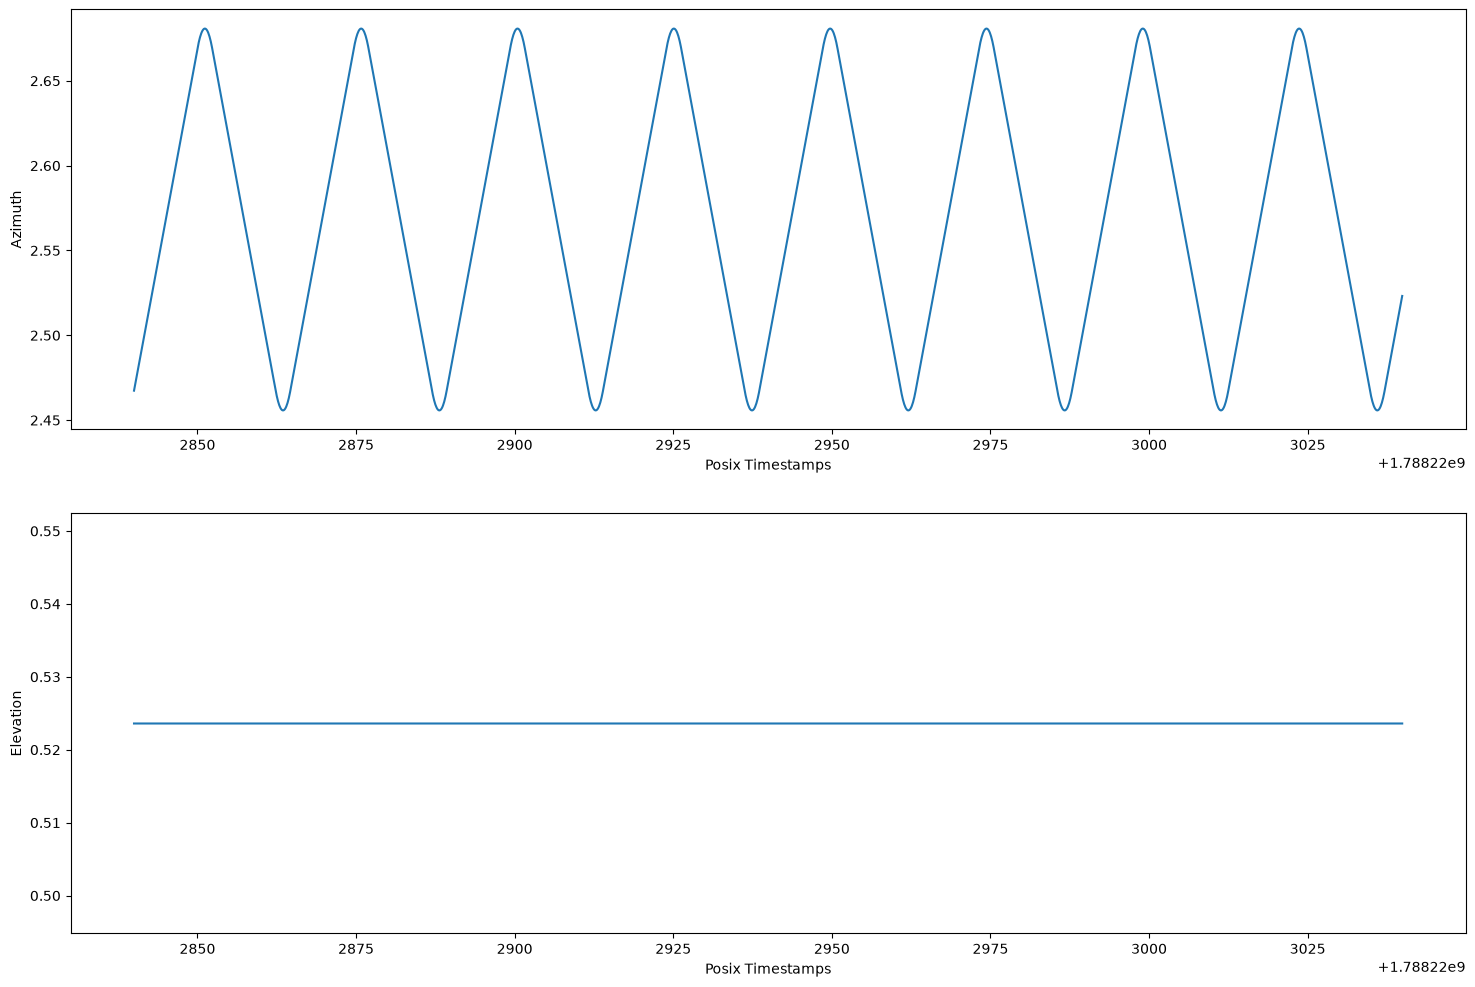

In [369]:
# Populate observations according to the schedule and telescope.
sim_ground = toast.ops.SimGround(
    telescope=telescope,
    weather="atacama",
    detset_key="pixel",
    schedule=schedule,
    median_weather=True, # no longer random weather, but less chance of an outlier
)

sim_ground.apply(data)

if rank == 0:
    plot_scanning(data.obs[0], s_start=0, s_end=2000)

## Inspecting the Observation

Now the data includes information about how the telescope will move.

In [370]:
print(data.obs)

[<Observation
  name = 'test-0-0'
  uid = '594457246'  group has 1 processes
  telescope = <Telescope 'HenryTelescope': uid = 2011423616, site = <GroundSite 'atacama' : uid = 39949029, lon = -67.7861111111111 deg, lat = -22.958333333333332 deg, alt = 5199.999999999725 m, weather = <SimWeather : 'atacama', year = 2026, month = 7, hour = 1, site UID = 39949029, realization = 0, median = True)>, focalplane = <Focalplane: 150 detectors, sample_rate = 10.0 Hz, FOV = 9.9 deg, detectors = [D00A-150 .. D74B-150]>>
  session = <Session 'test-0-0': uid = 1371551243, start = 2026-09-01 00:34:00+00:00, end = 2026-09-01 01:53:59.900000+00:00>
  scan_el = 30.0 deg
  scan_min_el = 0.5235987755982988 rad
  scan_max_el = 0.5235987755982988 rad
  scan_min_az = 2.4557364353139364 rad
  scan_max_az = 2.6807675502494854 rad
  48000 total samples (48000 local)
  shared:  <SharedDataManager
    times (column): shape=(np.int64(48000),), dtype=float64
    position (column): shape=(np.int64(48000), 3), dtype=fl

We can see that an `Observation` object was added to the data.

Let's inspect what is currently in that `Observation`.

Note: data stored in an observation can be split across MPI processes.

In [371]:
ob = data.obs[0]
# If we want to explore the detector data that is included
print(ob.detdata)
print(type(ob.detdata))

<DetDataManager 150 local detectors, 48000 samples
    signal: shape=(150, np.int64(48000)), dtype=float64, units='K'
    flags: shape=(150, np.int64(48000)), dtype=uint8, units=''>
<class 'toast.observation_data.DetDataManager'>


We can take a peak at some of the detector data

In [372]:
def get_det_slice(obs, det, slc, signal="signal"):
    return obs.detdata[signal][det, slc]

In [373]:
slc = slice(0,10,1)
det = "D00A-150"
det_slice = get_det_slice(ob, det, slc)
print(f"{slc} of detector {det}: {det_slice}")

slice(0, 10, 1) of detector D00A-150: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


As we can see, and as we expect the data is all empty.

## Detector Pointing

There are 3 types of operators that define the detector pointing:
1. The first is the geometric offset from the boresight coordinate frame to the detector coordinate frame. In the simplest case this is just a quaternion for each detector (stored in the focalplane table). 
2. Once the geometric detector pointing is computed, the pixelization on the sky is specified by a separate operator. 
3. Finally, the response of the detector to incoming Stokes parameters is given by another operator.

We will start by applying the geometric detector pointing from the boresight to the detector frame. We will define these for both horizontal and equatorial coordinates as the detector pointing in horizontal coordinates will be useful for atmosphere simulation later on.

In [374]:
det_point_azel = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)

print(det_point_azel)

det_point_radec = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_radec,
    quats="quats_radec"
)

<PointingDetectorSimple
  API = 0 # Internal interface version for this operator
  boresight = boresight_azel # Observation shared key for boresight
  coord_in = None # The input boresight coordinate system ('C', 'E', 'G')
  coord_out = None # The output coordinate system ('C', 'E', 'G')
  det_mask = 1 # Bit mask value for per-detector flagging
  enabled = True # If True, this class instance is marked as enabled
  hwp_angle = hwp_angle # Observation shared key for HWP angle
  hwp_angle_offset = 0.0 deg # HWP angle offset to apply when constructing deflection
  hwp_deflection_radius = None # If non-zero, nominal detector pointing will be deflected in a circular pattern according to HWP phase.
  kernel_implementation = 0 # Which kernel implementation to use (DEFAULT, COMPILED, NUMPY, JAX).
  name = PointingDetectorSimple # The 'name' of this class instance
  quats = quats_azel # Observation detdata key for output quaternions
  shared_flag_mask = 1 # Bit mask value for optional flagging
 

Even though the inputs (and attributes) of the `PointingDetectorSimple` are strings, these strings indicate how the detector pointing is adjust from the boresight frame.

In [375]:
# Pixelization.  Choose a coarse pixelization for this exercise since there is
# a small patch and only a few detectors.

nside = 256
pixels_radec = toast.ops.PixelsHealpix(
    nside=nside,
    nest=True,
    detector_pointing=det_point_radec,
)




In [376]:
# Stokes weights.  This just uses focalplane table properties to treat each detector
# as a linear polarizer with possibly some cross-polar response.

weights_azel = toast.ops.StokesWeights(
    mode="IQU",
    detector_pointing=det_point_azel,
)

weights_radec = toast.ops.StokesWeights(
    mode="IQU",
    detector_pointing=det_point_radec,
)

pixels_radec.apply(data)
weights_radec.apply(data)

At this point we have applied all the regular pointing operations

In [377]:
import toast.qarray as qa


In [378]:
def deflect_pointing(dxi, deta):
    defl_quat = toast.instrument_coords.xieta_to_quat(dxi, deta, 0.0)
    # print(defl_quat)
    # Apply deflection to the boresight pointing (in both azel and radec coordinates)
    if ob.comm_col_rank == 0:
        bore = qa.mult(ob.shared['boresight_azel'].data, qa.inv(defl_quat))
    else:
        bore = None
    # ob.shared['boresight_azel'].set(bore)

    if ob.comm_col_rank == 0:
        radec_bore = qa.mult(ob.shared['boresight_radec'].data, qa.inv(defl_quat))
    else:
        radec_bore = None
    # ob.shared['boresight_radec'].set(radec_bore)
    return bore, radec_bore

In [379]:

def random_defl(daz, d_el, sin_amp = 0.01, sin_freq=1, corotator_max=0.001):
    # Define the deflection in Xi Eta coordinates
    # Convert the lists to arrays
    max_daz = daz
    max_d_el = d_el

    num_samples = ob.shared['boresight_azel'].shape[0]
    # Make an array of random values between 0 and max
    az_rand_jitter = np.random.randn(num_samples)*daz - daz/2
    el_rand_jitter = np.random.randn(num_samples)*d_el - d_el/2
    corotator_jitter = np.random.randn(num_samples)*corotator_max - corotator_max/2
    
    az_sin = sin_amp*np.sin(sin_freq*np.arange(num_samples))
    el_sin = sin_amp*np.sin(sin_freq*np.arange(num_samples))

    lon_noise = -az_rand_jitter - az_sin
    lat_noise = el_rand_jitter + el_sin
    psi_noise = el_rand_jitter + el_sin
    # Convert the boresight quaternions to lonlat
    lon_arr, lat_arr, psi_arr = qa.to_lonlat_angles(ob.shared['boresight_azel'].data)
    
    # add the noise term
    lon_arr += lon_noise
    lat_arr += lat_noise
    psi_arr += psi_noise

    # Recompose into quaternions
    bore_azel = qa.from_lonlat_angles(lon_arr, lat_arr, psi_arr)
    ob.shared['boresight_azel'].set(bore_azel)

    ## RADEC
    lon_arr, lat_arr, psi_arr = qa.to_lonlat_angles(ob.shared['boresight_radec'].data)
    
    # add the noise term
    lon_arr += lon_noise
    lat_arr += lat_noise
    psi_arr += psi_noise
    
    # Recompose into quaternions
    boreradec = qa.from_lonlat_angles(lon_arr, lat_arr, psi_arr)
    ob.shared['boresight_radec'].set(boreradec)
    
    return bore_azel, boreradec


My own pointing visualization

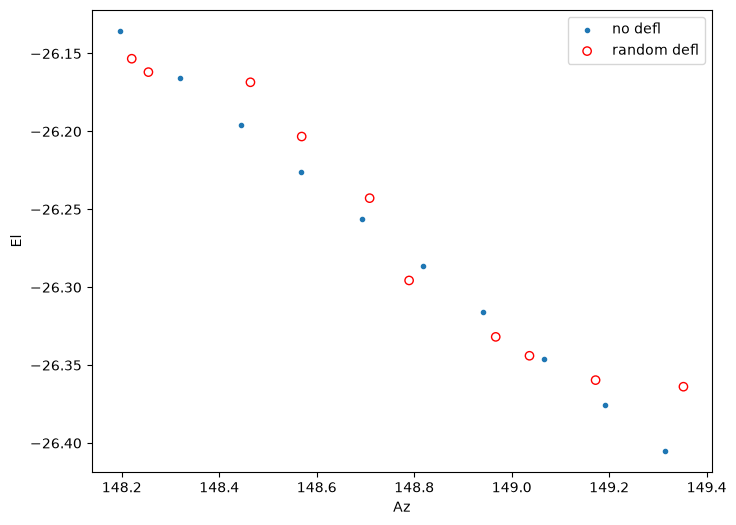

In [380]:
import so3g.proj.quat as quat

max_xi = ((80 * u.arcsec).to(u.rad)).value
max_eta = ((80 * u.arcsec).to(u.rad)).value

init_bore_azel = ob.shared['boresight_azel']
init_boreradec = np.array(ob.shared['boresight_radec'])
fig = plt.figure(figsize=(8,6))

bore_az, bore_el, _ = quat.decompose_lonlat(ob.shared['boresight_azel'].data)*np.array([-1, 1,1])[...,None]*180/np.pi
plt.scatter(bore_az[90:100], bore_el[90:100], marker='.', label=r'no defl')

# azel_bore, radec_bore = deflect_pointing(max_xi, 0)
# bore_az, bore_el, _ = quat.decompose_lonlat(azel_bore.data)*np.array([-1, 1,1])[...,None]*180/np.pi
# plt.plot(bore_az, bore_el, label=r'$\Delta\xi = 0.02$')

# azel_bore, radec_bore = deflect_pointing(0.0, max_eta)
# bore_az, bore_el, _ = quat.decompose_lonlat(azel_bore.data)*np.array([-1, 1,1])[...,None]*180/np.pi
# plt.plot(bore_az, bore_el, label=r'$\Delta\eta = 0.02$')


jitter_azel_bore, jitter_boreradec = random_defl(max_xi, max_eta, sin_amp= ((100 * u.arcsec).to(u.rad)).value, corotator_max = ((2 * u.arcsec).to(u.rad)).value)
bore_az, bore_el, _ = quat.decompose_lonlat(jitter_azel_bore.data)*np.array([-1, 1, 1])[...,None]*180/np.pi
plt.scatter(bore_az[90:100], bore_el[90:100], marker='o', facecolor="none", edgecolor='red', label=r'random defl')


plt.legend()
# plt.ylim(-24,-25)
# plt.xlim(142.5,143)
plt.xlabel('Az')
plt.ylabel("El")
plt.show()


# Pointing Visualization

In [381]:
from matplotlib.patches import Polygon
import plotly.tools as tls
import plotly.graph_objects as go

def calc_radius(coordinate, center_coord):
    return np.sqrt((coordinate[:, 0]-center_coord[0])**2 + (coordinate[:, 1]-center_coord[1])**2 )


In [ ]:

n_slices = 30
step_size = 20
boresight_coords = np.zeros((n_slices, 3))
init_boresight_coords = np.zeros((n_slices, 3))
 
fig = go.Figure()
# 3D figure made with the help of Claude AI
for i in range(n_slices):
    slc = slice(100 + step_size * i, 200 + step_size * i, step_size)

    ob_fp = ob.telescope.focalplane

    bquat = np.array(ob.shared[defaults.boresight_radec].data[slc, :])
    qbang = np.zeros((3, bquat.shape[0]), dtype=np.float64)
    qbang[0], qbang[1], qbang[2] = qa.to_lonlat_angles(bquat)
    qbang[0] *= 180.0 / np.pi
    qbang[1] *= 180.0 / np.pi

    boresight_coords[i] = np.array([qbang[0][0], qbang[1][0], i], dtype=float)

    bquat = np.array(init_boreradec[slc, :])
    qbang = np.zeros((3, bquat.shape[0]), dtype=np.float64)
    qbang[0], qbang[1], qbang[2] = qa.to_lonlat_angles(bquat)
    qbang[0] *= 180.0 / np.pi
    qbang[1] *= 180.0 / np.pi

    init_boresight_coords[i] = np.array([qbang[0][0], qbang[1][0], i], dtype=float)


    # Take only the first index
    all_dets = ob.local_detectors
    dets_quats = np.array([ob.detdata["quats_radec"][d][0, :] for d in all_dets])
    det_lon, det_lat, det_psi = qa.to_lonlat_angles(dets_quats)
    det_coords = np.column_stack((det_lon, det_lat))
    # Assume the mid lon/lat is the average of the min and max
    center_coord = (
        np.mean((np.max(det_lon), np.min(det_lon))),
        np.mean((np.max(det_lat), np.min(det_lat))),
    )
    det_radii = calc_radius(det_coords, center_coord)
    max_dist = np.max(det_radii)

    dets = np.array(ob.local_detectors)
    far_dets = dets[det_radii > 0.5 * max_dist]

    qdet = np.array([ob.detdata["quats_radec"][d][slc, :] for d in far_dets])

    n_qdet = len(qdet)
    n_samp = len(qdet[0])
    qdang = np.zeros((n_qdet, 3, n_samp), dtype=np.float64)
    for det in range(n_qdet):
        qdang[det, 0], qdang[det, 1], qdang[det, 2] = qa.to_lonlat_angles(qdet[det])
        qdang[det, 0] *= 180.0 / np.pi
        qdang[det, 1] *= 180.0 / np.pi


    # flatten all far-detectors' points for this slice into a single trace
    xs = qdang[:, 0, :].ravel()
    ys = qdang[:, 1, :].ravel()
    zs = np.full_like(xs, i)

    fig.add_trace(
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode="markers",
            marker=dict(
                size=2,
                symbol='diamond',
                opacity=0.5,
                color=zs,  # color by time (slice index)
                colorscale="Blues",
                cmin=0,
                cmax=n_slices - 1,
                showscale=(i == 0),  # only draw one colorbar, not one per slice
                colorbar=dict(title="Time (slice)", x=1.02) if i == 0 else None,
            ),
            name=f"slice {i}",
            showlegend=False,
        )
    )

bore_x, bore_y, bore_z = boresight_coords[:, 0], boresight_coords[:, 1], boresight_coords[:, 2]
fig.add_trace(
    go.Scatter3d(
        x=bore_x,
        y=bore_y,
        z=bore_z,
        mode="lines+markers",
        line=dict(color="blue", width=4),  # line itself can't take a colorscale
        marker=dict(
            size=4,
            color=bore_z,  # color by time (slice index)
            colorscale="viridis",
            cmin=0,
            cmax=n_slices - 1,
            showscale=True,
            colorbar=dict(title="Boresight time", x=1.15),
        ),
        name="Jitter Boresight",
    )
)

init_bore_x, init_bore_y, init_bore_z = init_boresight_coords[:, 0], init_boresight_coords[:, 1], init_boresight_coords[:, 2]
fig.add_trace(
    go.Scatter3d(
        x=init_bore_x,
        y=init_bore_y,
        z=init_bore_z,
        mode="lines+markers",
        line=dict(color="indianred", width=4),  # line itself can't take a colorscale
        marker=dict(
            size=4,
            color=init_bore_z,  # color by time (slice index)
            colorscale="Reds",
            cmin=0,
            cmax=n_slices - 1,
            showscale=True,
            colorbar=dict(title="Boresight time", x=1.15),
        ),
        name="Init Boresight",
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="Longitude (deg)",
        yaxis_title="Latitude (deg)",
        zaxis_title="Slice index",
    ),
    width=900,
    height=900,
    title="Detector pointing per slice",
)

fig.write_html("boresight_plot.html")
fig.show()

In [ ]:
print(bore_x - init_bore_x)


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [ ]:
slc = slice(100, 1100, 500)

# Boresight quaternion for the slice — use boresight_azel for ground data,
# boresight_radec if you want celestial coordinates
bquat = np.array(ob.shared[defaults.boresight_radec].data[slc, :])
print(ob.detdata)
# Detector quaternions for the slice, shape (n_det, n_samp, 4)
dets = ob.local_detectors
print(dets)
dquat = np.array([ob.detdata["quats_radec"][d][slc, :] for d in dets])
# Mask out flagged samples
invalid = np.array(ob.shared[defaults.shared_flags][slc])
invalid &= defaults.shared_mask_invalid
valid = np.logical_not(invalid)

plot_projected_quats(
    os.path.join(out_dir, "pointing.png"),
    qbore=bquat,
    qdet=dquat,
    valid=valid,
    scale=1.0,
)
plt.show()

<DetDataManager 150 local detectors, 48000 samples
    signal: shape=(150, np.int64(48000)), dtype=float64, units='K'
    flags: shape=(150, np.int64(48000)), dtype=uint8, units=''
    quats_radec: shape=(150, np.int64(48000), 4), dtype=float64, units=''
    pixels: shape=(150, np.int64(48000)), dtype=int64, units=''
    weights: shape=(150, np.int64(48000), 3), dtype=float64, units=''>
[np.str_('D00A-150'), np.str_('D00B-150'), np.str_('D01A-150'), np.str_('D01B-150'), np.str_('D02A-150'), np.str_('D02B-150'), np.str_('D03A-150'), np.str_('D03B-150'), np.str_('D04A-150'), np.str_('D04B-150'), np.str_('D05A-150'), np.str_('D05B-150'), np.str_('D06A-150'), np.str_('D06B-150'), np.str_('D07A-150'), np.str_('D07B-150'), np.str_('D08A-150'), np.str_('D08B-150'), np.str_('D09A-150'), np.str_('D09B-150'), np.str_('D10A-150'), np.str_('D10B-150'), np.str_('D11A-150'), np.str_('D11B-150'), np.str_('D12A-150'), np.str_('D12B-150'), np.str_('D13A-150'), np.str_('D13B-150'), np.str_('D14A-150'), 